Fig. 4

In [134]:
import numpy as np
import string
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import Circle
from matplotlib.patches import Arrow
import matplotlib as mpl
from PIL import Image
from matplotlib import patheffects
from math import cos, sin, pi
from matplotlib import gridspec

plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 2,
    'ytick.major.size': 2,
    # 'xtick.major.pad': 3,
    # 'ytick.major.pad': 3,
})

In [2]:
normal_points = [(6, 12), (0, 7), (6, 0), (8, 10), (4, 5), (14, 5), (12, 3)]
steiner_points = [(6, 5), (6, 7), (6, 10), (8, 3), (12, 10), (12, 5), (6, 3), (4, 7)]
normal_labels = list(string.ascii_uppercase[:len(normal_points)])
steiner_labels = list(string.ascii_lowercase[:len(steiner_points)])
rectangles = [
{'xy': (-0.5, 12.5), 'width': 7.5, 'height': 1.6, 'edgecolor': 'k', 'facecolor': '0.8', 'linewidth': 1},
{'xy': (-0.5, 7.5), 'width': 2.8, 'height': 3.6, 'edgecolor': 'k', 'facecolor': '0.8', 'linewidth': 1},
{'xy': (-0.5, 3.7), 'width': 4, 'height': 2, 'edgecolor': 'k', 'facecolor': '0.8', 'linewidth': 1},
{'xy': (7, 7.5), 'width': 2, 'height': 2.1, 'edgecolor': 'k', 'facecolor': '0.8', 'linewidth': 1},
{'xy': (13.5, 0.7), 'width': 2, 'height': 3.8, 'edgecolor': 'k', 'facecolor': '0.8', 'linewidth': 1},
{'xy': (-0.5, -1.2), 'width': 5.9, 'height': 2.5, 'edgecolor': 'k', 'facecolor': '0.8', 'linewidth': 1},
{'xy': (8.7, 0.7), 'width': 3.7, 'height': 1.8, 'edgecolor': 'k', 'facecolor': '0.8', 'linewidth': 1}
]

In [ ]:
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        return np.min(zs)
    
def plot_3d_steiner_tree(normal_points, steiner_points, rectangles, adjacency_matrix):
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_proj_type('ortho')
    
    z_plane = 0.1
    normal_points_3d = [(x, y, z_plane) for x, y in normal_points]
    steiner_points_3d = [(x, y, z_plane) for x, y in steiner_points]
    
    normal_x, normal_y, normal_z = zip(*normal_points_3d)
    ax.scatter(normal_x, normal_y, normal_z, color='#ff4f4f', s=30, edgecolor="k", linewidths=0.8,
              label='Terminal vertices', zorder=3, depthshade=False)
    for idx, point in enumerate(normal_points_3d):
        if idx == 0:
            shift_x = -1.2
            shift_y = -1
        elif idx == 4:
            shift_x = -0.3
            shift_y = -1.5
        elif idx == 1:
            shift_x = 0.3
            shift_y = -0.6
        else:
            shift_x = 0.3
            shift_y = 0
        ax.text(point[0] + shift_x, point[1]+shift_y, point[2], str(idx), 
                zorder=10, color='black')

    steiner_x, steiner_y, steiner_z = zip(*steiner_points_3d)
    ax.scatter(steiner_x, steiner_y, steiner_z, color='#a0a0ff', s=30, edgecolor="k", linewidths=0.8,
              label='Steiner vertices', zorder=3, depthshade=False)
    for idx, point in enumerate(steiner_points_3d):
        if idx + len(normal_points) == 9:
            shift_x = -1.2
            shift_y = -1
        elif idx + len(normal_points) == 8:
            shift_x = -1.0
            shift_y = 0
        elif idx + len(normal_points) == 7:
            shift_x = 0
            shift_y = 0.7
        elif idx + len(normal_points) == 14:
            shift_x = -1.5
            shift_y = 0
        elif idx + len(normal_points) == 12:
            shift_x = -1
            shift_y = 1
        else:
            shift_x = 0.3
            shift_y = 0
        ax.text(point[0] + shift_x, point[1]+shift_y, point[2], 
                str(idx + len(normal_points)), zorder=10, color='black')
    
    all_points = normal_points_3d + steiner_points_3d
    n = len(all_points)
    for i in range(n):
        for j in range(n):
            if adjacency_matrix[i][j] == 1:
                arrow = Arrow3D([all_points[i][0], all_points[j][0]],
                          [all_points[i][1], all_points[j][1]],
                          [all_points[i][2], all_points[j][2]],
                          mutation_scale=5,  
                          lw=1,              
                          arrowstyle='-|>',  
                          color='black',     
                          alpha=1.0)         
                ax.add_artist(arrow)
    
    height = 0.1
    for rect in rectangles:
        x, y = rect['xy']
        w, h = rect['width'], rect['height']
        
        vertices = np.array([
            [[x, y, 0], [x+w, y, 0], [x+w, y+h, 0], [x, y+h, 0]],
            [[x, y, height], [x+w, y, height], [x+w, y+h, height], [x, y+h, height]]
        ])
        
        top_face = [vertices[1][0], vertices[1][1], vertices[1][2], vertices[1][3]]
        bottom_face = [vertices[0][0], vertices[0][1], vertices[0][2], vertices[0][3]]
        other_faces = []
        #other_faces.append(bottom_face)
        for i in range(4):
            j = (i + 1) % 4
            other_faces.append([vertices[0][i], vertices[0][j], vertices[1][j], vertices[1][i]])
        
        poly3d_other = Poly3DCollection(other_faces, alpha=0.3, facecolor='0.4', edgecolor='k', zorder=2)
        ax.add_collection3d(poly3d_other)
        
        poly3d_top = Poly3DCollection([top_face], alpha=1, facecolor='peachpuff', edgecolor='k', zorder=3, linewidths=0.5)
        ax.add_collection3d(poly3d_top)

        #draw_3d_transistors(ax, rect)
    
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    #y_min -= 1
    xx, yy = np.meshgrid([x_min, x_max], [y_min, y_max])
    #zz = np.full_like(xx, z_plane)
    #ax.plot_surface(xx, yy, zz, alpha=0.1, color='green')
    zz = np.full_like(xx, 0)
    ax.plot_surface(xx, yy, zz, alpha=0.1, color='#FFDAB9')

    ax.set_zlim(0,2)
    ax.set_axis_off()
    
    ax.view_init(elev=30, azim=-105)
    ax.legend(loc='upper left', bbox_to_anchor=(0.18, 0.55), frameon=False, handletextpad=0.2)
    plt.savefig(
                "./plot/Fig4a.svg",dpi=800,
                bbox_inches='tight'
                )
    plt.show()

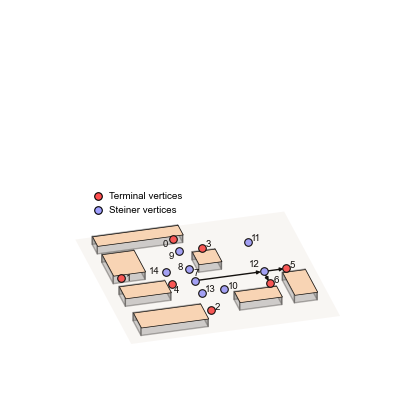

In [4]:
n_total = len(normal_points) + len(steiner_points)
adjacency_matrix = np.zeros((n_total, n_total))
adjacency_matrix[12][5] = 1
adjacency_matrix[12][6] = 1
adjacency_matrix[7][12] = 1

plot_3d_steiner_tree(normal_points, steiner_points, rectangles, adjacency_matrix)

In [ ]:
def plot_sparse_matrix_with_circles(array,flag):
    assert array.shape == (15, 15), "Input matrix must be 15x15"
    
    fig = plt.figure(figsize=(2.3, 2.3))
    ax = fig.add_subplot(111)
    
    ax.set_xlim(-2, 12)
    ax.set_ylim(-1, 13)
    ax.set_aspect('equal')
    
    arrow_width = 0.3
    arrow_length = 0.57
    arrow_offset = 0.3
    
    def draw_circle_with_arrow(is_abandoned, value, x, y):
        if is_abandoned:
            color = (200/255, 200/255, 200/255)
            alpha = 0.3
            ec = "none"
            d = 0.4
        else:
            if value == 1:
                color = (125/255, 223/255, 215/255)
                alpha = 1.0
                ec = "k"
                d = 0.4
            elif value == -1:
                color = (239/255, 148/255, 158/255)
                alpha = 1.0
                ec = "k"
                d = 0.4
            elif value == 0:
                #color = (218/255, 227/255, 245/255)
                color = (252/255, 230/255, 213/255)
                alpha = 0.4
                ec = "k"
                d = 0.4
            else:
                color = "gray"
                alpha = 0.5
                ec = "none"
                d = 0.48
            
        circle = Circle((x, y), radius=d,
                      facecolor=color,
                      alpha=alpha,
                      edgecolor=ec)
        ax.add_patch(circle)
        
        if value == 1:
            arrow = Arrow(x, y-arrow_offset, 0, arrow_length,
                        width=arrow_width,
                        color='k')
            ax.add_patch(arrow)
        elif value == -1:
            arrow = Arrow(x, y+arrow_offset, 0, -arrow_length,
                        width=arrow_width,
                        color='k')
            ax.add_patch(arrow)
    
    corners = [(0,0), (0,11), (11,0), (11,11)]
    for i, j in corners:
        if flag == 2:
            is_abandoned = True if i==j else False
        if flag == 3:
            is_abandoned = True if i>=j else False
        draw_circle_with_arrow(is_abandoned, array[i,j], j if j<11 else 11, 11-i if i<11 else 0)
    
    for j in range(2, 10):
        draw_circle_with_arrow(False,array[0,j+5], j, 11)
        draw_circle_with_arrow(False if flag==2 else True,array[11,j+5], j, 0)
    
    for i in range(2, 10):
        draw_circle_with_arrow(False if flag==2 else True,array[i+5,0], 0, 11-i)
        draw_circle_with_arrow(False,array[i+5,11], 11, 11-i)
    
    for i in range(8):
        for j in range(8):
            if flag == 2:
                is_abandoned = True if i == j else False
            elif flag == 3:
                is_abandoned = True if i >= j else False
            if array[i+5,j+5] == 1 or array[i+5,j+5] == -1:
                draw_circle_with_arrow(is_abandoned, 2, j+2, 9-i)
            draw_circle_with_arrow(is_abandoned, array[i+5,j+5], j+2, 9-i)
    
    def add_dots(x, y, d):
        if d:
            plt.plot([x-0.2, x, x+0.2], [y, y, y], 'k.',markersize=2)
        else:
            plt.plot([x, x, x], [y-0.2, y, y+0.2], 'k.',markersize=2)
    
    add_dots(1, 11, 1)
    add_dots(10, 11, 1)
    add_dots(1, 9, 1)
    add_dots(10, 9, 1)
    add_dots(1, 2, 1)
    add_dots(10, 2, 1)
    add_dots(1, 0, 1)
    add_dots(10, 0, 1)
    add_dots(0, 10, 0)
    add_dots(0, 1, 0)
    add_dots(2, 10, 0)
    add_dots(2, 1, 0)
    add_dots(9, 10, 0)
    add_dots(9, 1, 0)
    add_dots(11, 10, 0)
    add_dots(11, 1, 0)
    
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    ax.add_patch(FancyArrowPatch((-1.19, 12), (12, 12),
                                arrowstyle='-|>',
                                mutation_scale=10,
                                color='black'))
    ax.add_patch(FancyArrowPatch((-1, 12.19), (-1, -1),
                                arrowstyle='-|>',
                                mutation_scale=10,
                                color='black'))
    
    plt.text(12.0, 12.0, 'n', fontsize=9)
    plt.text(-1.6, -1.5, 'm', fontsize=9)
    
    ticks_pos = [0, 2, 9, 11]
    ticks_labels = [0, 5, 12, 14]
    
    for pos, label in zip(ticks_pos, ticks_labels):
        plt.text(pos, 12.2, str(label), ha='center', va='bottom')
        plt.plot([pos, pos], [11.9, 11.8], 'k-')
        
    for pos, label in zip(ticks_pos, ticks_labels):
        plt.text(-1.2, 11-pos, str(label), ha='right', va='center')
        plt.plot([-0.9, -0.8], [11-pos, 11-pos], 'k-')
    
    if flag == 2:
        filename = "Fig4b_left.svg"
    elif flag == 3:
        filename = "Fig4b_right.svg"
    plt.grid(False)
    plt.savefig(
                "./plot/"+filename,dpi=800,
                bbox_inches='tight'
                )
    plt.show()

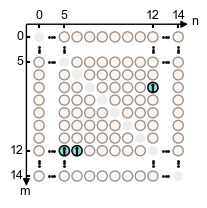

In [28]:
plot_sparse_matrix_with_circles(adjacency_matrix,2)

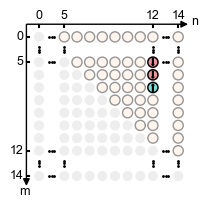

In [29]:
adjacency_matrix_x = np.zeros((n_total, n_total))
adjacency_matrix_x[5][12] = -1
adjacency_matrix_x[6][12] = -1
adjacency_matrix_x[7][12] = 1
plot_sparse_matrix_with_circles(adjacency_matrix_x,3)

In [ ]:
def draw_subplot(ax, points, lines, radius=4, ising=False, order=0):
    shadow_radius = radius + 0.3
    shadow_offset = 0.0
    shadow_circle = plt.Circle((shadow_offset, -shadow_offset), shadow_radius, 
                             fill=True, alpha=0.1, 
                             fc='gray', ec='none', zorder=1)
    ax.add_patch(shadow_circle)
    
    circle = plt.Circle((0, 0), radius, fill=True, alpha=0.5, 
                       fc='#FFFF88', ls='--', ec='none', zorder=2)
    ax.add_patch(circle)
    
    for x, y, flag in points:
        if not ising:
            color = '#ff4f4f' if flag == 0 else '#a0a0ff'
        else:
            color = '#F5B482' if flag == 0 else '#7DDFD7'
        ax.scatter(x, y, color=color, s=50, zorder=4, edgecolor="k")
    
    for x1, y1, x2, y2 in lines:
        if not ising:
            lwd = 1
        else:
            lwd = 0.5
        ax.plot([x1, x2], [y1, y2], 'k-', linewidth=lwd, zorder=3)
    
    if order == 0:
        ax.text(0,5.5,f"Objective", horizontalalignment='center', verticalalignment='bottom', zorder=4, color='black')
    elif order < 5:
        ax.text(0,5.5,f"Constraint {order}", horizontalalignment='center', verticalalignment='bottom', zorder=4, color='black')
    else:
        ax.text(0,6.2,f"Ising model", horizontalalignment='center', verticalalignment='bottom', zorder=4, color='black')
    
    texts = ["Minimum cost","Arcs of terminal vertices","Acyclicity","Arcs of Steiner vertices","Rectilinearity"]
    if order <5:
        ax.text(0,-6,texts[order], horizontalalignment='center', verticalalignment='bottom', zorder=4, color='black')
    
    ax.set_aspect('equal')
    ax.axis('off')
    
    limit = max(radius + 0.4, 5)
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)

def generate_16_points_graph():
    n_points = 16
    radius = 4
    points = []
    for i in range(n_points):
        angle = 2 * pi * i / n_points
        x = radius * cos(angle)
        y = radius * sin(angle)
        point_type = np.random.choice([0, 1])
        points.append((x, y, point_type))
    
    lines = []
    for i in range(n_points-1):
        lines.append((points[i][0], points[i][1], 
                     points[i+1][0], points[i+1][1]))
    
    n_extra_edges = 15
    possible_edges = [(i, j) for i in range(n_points) for j in range(i+2, n_points)]
    selected_edges = np.random.choice(len(possible_edges), 
                                    n_extra_edges, replace=False)
    
    for edge_idx in selected_edges:
        i, j = possible_edges[edge_idx]
        lines.append((points[i][0], points[i][1], 
                     points[j][0], points[j][1]))
    
    return points, lines

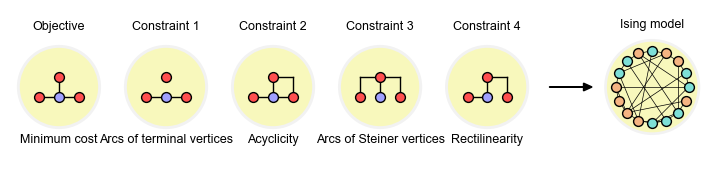

In [ ]:
fig = plt.figure(figsize=(7.2, 2))

gs = gridspec.GridSpec(1, 7, 
                          width_ratios=[1, 1, 1, 1, 1, 0.5, 1])
gs.update(wspace=0.1, left=0.02, right=0.98, hspace=0.4)

steiner_points_list = []
steiner_lines_list = []

steiner_points_1 = [(0, -1, 1), (-2, -1, 0), (2, -1, 0), (0, 1, 0)]
steiner_points_list.append(steiner_points_1)
steiner_lines_1 = [(0, -1, -2, -1), (0, -1, 2, -1), (0, -1, 0, 1)]
steiner_lines_list.append(steiner_lines_1)

steiner_points_2 = [(0, -1, 1), (-2, -1, 0), (2, -1, 0), (0, 1, 0)]
steiner_points_list.append(steiner_points_2)
steiner_lines_2 = [(0, -1, -2, -1), (0, -1, 2, -1)]
steiner_lines_list.append(steiner_lines_2)

steiner_points_3 = [(0, -1, 1), (-2, -1, 0), (2, -1, 0), (0, 1, 0)]
steiner_points_list.append(steiner_points_3)
steiner_lines_3 = [(0, -1, -2, -1), (0, -1, 2, -1), (0, -1, 0, 1), (0, 1, 2, 1), (2, 1, 2, -1)]
steiner_lines_list.append(steiner_lines_3)

steiner_points_4 = [(0, -1, 1), (-2, -1, 0), (2, -1, 0), (0, 1, 0)]
steiner_points_list.append(steiner_points_4)
steiner_lines_4 = [(0, 1, -2, 1), (-2, -1, -2, 1), (0, -1, 0, 1), (0, 1, 2, 1), (2, 1, 2, -1)]
steiner_lines_list.append(steiner_lines_4)

steiner_points_5 = [(0, -1, 1), (-2, -1, 0), (2, -1, 0), (0, 1, 0)]
steiner_points_list.append(steiner_points_5)
steiner_lines_5 = [(0, -1, -2, -1), (0, -1, 0, 1), (0, 1, 2, 1), (2, 1, 2, -1)]
steiner_lines_list.append(steiner_lines_5)

complex_points, complex_lines = generate_16_points_graph()

for i in range(7):
    ax = plt.subplot(gs[i])
    
    if i == 5:
        ax.axis('off')
        ax.arrow(0, 0, 2, 0,
                head_width=0.03,
                head_length=0.4,
                fc='black',
                ec='black',
                length_includes_head=True)
        ax.set_xlim(-0.2, 2.1)
        ax.set_ylim(-0.3, 0.3)
    elif i < 5:
        draw_subplot(ax, steiner_points_list[i], steiner_lines_list[i], radius=4, ising=False, order=i)
    else:
        draw_subplot(ax, complex_points, complex_lines, radius=5, ising=True, order=i)

plt.savefig("./plot/Fig4c.svg",bbox_inches='tight',dpi=800)
plt.show()


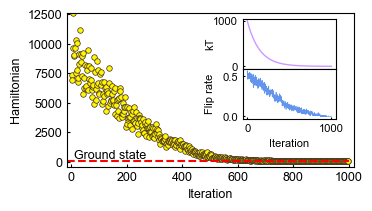

In [135]:
def manhattan_distance(p1, p2):
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

def broken_line(p1, p2):
    if (p1[0]==p2[0]) or (p1[1]==p2[1]):
        return 0
    else:
        return 1

def calculate_Hamiltonian(s, var_num, V_num, U_num, dist_matrix, is_broken_line):
    e = (s[0:V_num,:] + 1) // 2
    x = (s[V_num:var_num,:] + 1) // 2
    Hc1 = 0
    for n in range(1,U_num):
        Hc1 += (sum(e[m,n] for m in range(V_num) if m != n) - 1)**2
    Hc2 = 0
    for k in range(3, V_num):
        for m in range(1, k-1):
            for n in range(m+1, k):
                Hc2 += x[m,k]+x[m,n]*x[n,k]-x[m,n]*x[m,k]-x[m,k]*x[n,k]
    Hc3 = 0
    for n in range(2,V_num):
        for m in range(1,n):
            Hc3 += e[m,n]*(1-x[m,n])+e[n,m]*x[m,n]
    Hc4 = 0
    for n in range(U_num,V_num):
        for m in range(V_num):
            for k in range(m+1,V_num):
                if m != n and k != n:
                    Hc4 += V_num*e[m,n]*e[k,n]
    Hc5 = 0
    for n in range(U_num,V_num):
        temp1 = 1 - sum(e[m,n] for m in range(V_num) if m != n)
        temp2 = sum(e[n,m] for m in range(1,V_num) if m != n)
        Hc5 += temp1*temp2

    Hc6 = 0
    for m in range(V_num):
        for n in range(1,V_num):
            Hc6 += is_broken_line[m,n] * e[m,n]

    Opt = 0
    for m in range(V_num):
        for n in range(1,V_num):
            Opt += dist_matrix[m,n] * e[m,n]

    return Opt,Hc1,Hc2,Hc3,Hc4,Hc5,Hc6


normal_points = [(6, 12), (0, 7), (6, 0), (8, 10), (14, 5), (4, 5), (12, 3)]
steiner_points = [(6, 5), (6, 7), (6, 10), (8, 3), (12, 10), (12, 5), (6, 3), (4, 7)]
all_points = normal_points + steiner_points
V_num = len(all_points)
var_num = 2 * V_num
U_num = len(normal_points)
dist_matrix = np.zeros((V_num,V_num),dtype=np.int16)
is_broken_line = np.zeros((V_num,V_num),dtype=np.int16)

for i, p1 in enumerate(all_points):
    for j, p2 in enumerate(all_points):
        if i != j:
            dist_matrix[i,j] = manhattan_distance(p1, p2)
            is_broken_line[i,j] = broken_line(p1, p2)

lambda_A = 10
lambda_B = 10
lambda_C = 6
lambda_D = 6
T_max = 1000
s_process = np.load(f"./data/Fig4/MTJ_s_process.npy")
T_min = 1
Iteration = s_process.shape[0]
decay = pow(T_min/T_max,1.0/Iteration)
H = np.zeros((Iteration,))
for i in range(Iteration):
    Opt,Hc1,Hc2,Hc3,Hc4,Hc5,Hc6 = calculate_Hamiltonian(s_process[i,:,:], var_num, V_num, U_num, dist_matrix, is_broken_line)
    H[i] = Opt + lambda_A*Hc1 + lambda_B*(Hc2+Hc3) + lambda_C*(Hc4+Hc5) + lambda_D*Hc6

ground = np.min(H)
# print(ground)
Iter_plot = np.arange(1,Iteration+1)
T_plot = T_max * (decay ** Iter_plot)

flip_rate = np.zeros((Iteration,))
for i in range(Iteration-1):
    flip_num = 0
    for m in range(V_num):
        for n in range(1,V_num):
            if m != n and s_process[i,m,n] != s_process[i+1,m,n]:
                flip_num += 1
    flip_rate[i] = flip_num / ((V_num-2)*V_num)

fig, ax = plt.subplots(figsize=(3.7,2.0))
interval = 2
Iter_plot_1 = Iter_plot[::interval]
H_plot = H[::interval]
linecolor = '#3E2723'
ax.plot(Iter_plot_1 , H_plot,lw=0.5,linestyle='none', color=linecolor, marker="o", markersize=4, markerfacecolor='#FFF700', markeredgecolor=linecolor,markeredgewidth=0.5)
ax.plot([-15, Iter_plot[-1]], [ground, ground], 'r--')
ax.text(10, ground+200, 'Ground state', color='k')
ax.set_xlim(-15, Iter_plot[-1]+20)
ax.set_ylim(-400, max(H) + 10)
ax.set_xlabel("Iteration")
ax.set_ylabel("Hamiltonian")

ax_inset_1 = fig.add_axes([0.6, 0.6, 0.25, 0.25])
ax_inset_1.plot(Iter_plot, T_plot, color='#CC99FF', alpha=1, lw=1)
ax_inset_1.yaxis.set_label_coords(x=-0.3, y=0.5)

ax_inset_2 = fig.add_axes([0.6, 0.35, 0.25, 0.25])
ax_inset_2.plot(Iter_plot, flip_rate, color='cornflowerblue', alpha=1, lw=0.5)
ax_inset_2.yaxis.set_label_coords(x=-0.3, y=0.5)

ax_inset_1.set_ylabel('kT', fontsize=8)
ax_inset_1.tick_params(labelsize=8, direction='in',length=1.5)
ax_inset_1.set_xticks([])

ax_inset_2.set_xlabel('Iteration', fontsize=8)
ax_inset_2.set_ylabel('Flip rate', fontsize=8)
ax_inset_2.tick_params(labelsize=8, direction='in',length=1.5)
plt.savefig(f"./plot/Fig4d.svg", bbox_inches='tight',dpi=800)
plt.show()

Number of terminal vertices:7
Number of Steiner vertices:8
Size of set V:15
Number of variables:30


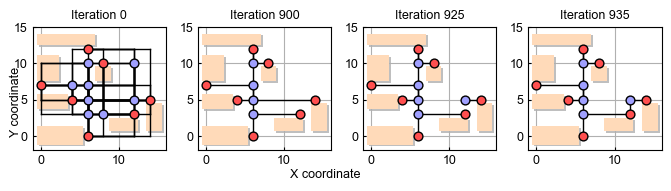

In [ ]:
import string
import matplotlib.transforms as mtransforms

normal_points = [(6, 12), (0, 7), (6, 0), (8, 10), (14, 5), (4, 5), (12, 3)]
steiner_points = [(6, 5), (6, 7), (6, 10), (8, 3), (12, 10), (12, 5), (6, 3), (4, 7)]

normal_labels = list(string.ascii_uppercase[:len(normal_points)])
steiner_labels = list(string.ascii_lowercase[:len(steiner_points)])
all_labels = normal_labels + steiner_labels

def manhattan_distance(p1, p2):
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

all_points = normal_points + steiner_points
V_num = len(all_points)
var_num = 2 * V_num
U_num = len(normal_points)
dist_matrix = np.zeros((V_num,V_num),dtype=np.int16)

for i, p1 in enumerate(all_points):
    for j, p2 in enumerate(all_points):
        if i != j:
            dist_matrix[i,j] = manhattan_distance(p1, p2)

# print(f"Number of terminal vertices:{len(normal_points)}")
# print(f"Number of Steiner vertices:{len(steiner_points)}")
# print(f"Size of set V:{V_num}")
# print(f"Number of variables:{var_num}")

rectangles = [
    {'xy': (-0.5, 12.5), 'width': 7.5, 'height': 1.6, 'edgecolor': 'k', 'facecolor': '0.8', 'linewidth': 1},
    {'xy': (-0.5, 7.5), 'width': 2.8, 'height': 3.6, 'edgecolor': 'k', 'facecolor': '0.8', 'linewidth': 1},
    {'xy': (-0.5, 3.7), 'width': 4, 'height': 2, 'edgecolor': 'k', 'facecolor': '0.8', 'linewidth': 1},
    {'xy': (7, 7.5), 'width': 2, 'height': 2.1, 'edgecolor': 'k', 'facecolor': '0.8', 'linewidth': 1},
    {'xy': (13.5, 0.7), 'width': 2, 'height': 3.8, 'edgecolor': 'k', 'facecolor': '0.8', 'linewidth': 1},
    {'xy': (-0.5, -1.2), 'width': 5.9, 'height': 2.5, 'edgecolor': 'k', 'facecolor': '0.8', 'linewidth': 1},
    {'xy': (8.7, 0.7), 'width': 3.7, 'height': 1.8, 'edgecolor': 'k', 'facecolor': '0.8', 'linewidth': 1}
]

pos = {all_labels[i]: point for i, point in enumerate(all_points)}

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(7.0, 2.1))
color_list = ['#ff4f4f','#a0a0ff','peachpuff'] #r b o
normal_x, normal_y = zip(*normal_points)
s_num = [0,900,925,935]
s_process = np.load("./data/Fig4/MTJ_s_process.npy")
for i in range(4):
    s_out = s_process[s_num[i],:,:]
    tree = []
    total_weight = 0
    check_visited = [0] * V_num
    for m in range(V_num):
        for n in range(1,V_num):
            if m != n and s_out[m,n] == 1:
                v1 = all_labels[m]
                v2 = all_labels[n]
                weight = dist_matrix[m,n]
                tree.append((v1, v2, weight))
                total_weight += weight
                check_visited[m] = 1
                check_visited[n] = 1

    sel_id = []
    for k in range(U_num,V_num):
        if check_visited[k]:
            sel_id.append(k-U_num)

    ax[i].scatter(normal_x, normal_y, color=color_list[0], s=40, label='Terminal Vertices', zorder=4, edgecolor="k")

    selected_steiner_points = [steiner_points[i] for i in sel_id]

    if selected_steiner_points:
        selected_x, selected_y = zip(*selected_steiner_points)
        ax[i].scatter(selected_x, selected_y, color=color_list[1], s=40, label='Steiner Vertices', zorder=4, edgecolor="k")

    for edge in tree:
        node1, node2 = edge[0], edge[1]
        x1, y1 = pos[node1]
        x2, y2 = pos[node2]
        
        ax[i].plot([x1, x2], [y1, y1], color='k', linewidth=1, zorder=3)
        ax[i].plot([x2, x2], [y1, y2], color='k', linewidth=1, zorder=3)

    for rect in rectangles:
        rect_patch = plt.Rectangle(rect['xy'], rect['width'], rect['height'],
                                 facecolor=color_list[2],
                                 edgecolor='none',
                                 alpha=1,
                                 zorder=2)
        
        shadow = plt.Rectangle(rect['xy'], rect['width'], rect['height'],
                             facecolor='gray',
                             edgecolor='none',
                             alpha=0.5,
                             transform=mtransforms.Affine2D().translate(0.25, -0.25) + ax[i].transData,
                             zorder=1)
        
        ax[i].add_patch(shadow)
        ax[i].add_patch(rect_patch)

    ax[i].grid(True, zorder=1)
    ax[i].set_xlim(-1,16)
    ax[i].set_ylim(-2,15)
    ax[i].set_title(f"Iteration {s_num[i]}", fontsize=9)

fig.supxlabel('X coordinate', y=0.12, fontsize=9)
fig.supylabel('Y coordinate', x=0.05, fontsize=9)
plt.tight_layout()
plt.savefig("./plot/Fig4e.svg", bbox_inches='tight',dpi=800)
plt.show()

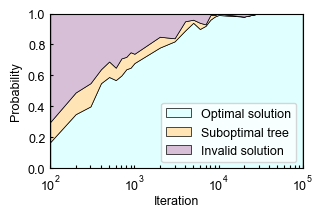

In [ ]:
import pandas as pd
file_path = './data/Fig4/success_probability.xlsx'
color_list = ['#E0FFFF', '#FFE4B5', '#D8BFD8']  #b o p

param_name = "Iteration_MTJ"
df = pd.read_excel(file_path, skiprows=1, header=None, sheet_name=param_name)
Iterations = df[4].tolist()
probability_of_success = df[9].tolist()
probability_of_not_shortest = df[10].tolist()
probability_of_not_tree = df[11].tolist()

fig,ax = plt.subplots(figsize=(3.3, 2.25))
plt.stackplot(Iterations, probability_of_success, probability_of_not_shortest, probability_of_not_tree, labels=['Optimal solution', 'Suboptimal tree', 'Invalid solution'], colors=color_list, edgecolor='black', linewidth=0.5)
plt.xscale('log')

plt.xlabel("Iteration", labelpad=1)
X = np.array(Iterations)
plt.xlim(X.min(), X.max())
ax.set_xticks(X)
plt.ylabel("Probability")
plt.ylim(0, 1)
plt.legend(loc='best')
plt.tight_layout()
plt.savefig(f"./plot/Fig4f.svg", bbox_inches='tight', dpi=800)

plt.show()